# Reef Analysis B - Aggregated Dataset (One Row per Reef)


In this analysis, we use an aggregated version of the dataset, where each reef site is represented
by a single row obtained by averaging observations across time.

The goal of this analysis is to:
- Remove sampling bias caused by uneven observation counts across reefs
- Treat each reef equally in the analysis
- Identify underlying environmental structure at the reef level using PCA
- Compare clustering patterns with those observed in the full dataset (Analysis A)

Note:
This aggregation removes temporal variation, allowing us to focus on overall differences between reefs
rather than changes over time.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

df = pd.read_csv("cleaned_data/dataset_B.csv")

# Recompute feature cols:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = ["Site_ID", "Percent_Bleaching"]

feature_cols = [c for c in numeric_cols if c not in exclude_cols]

X = df[feature_cols].copy()

X.head()

,Sample_ID,Latitude_Degrees,Longitude_Degrees,Distance_to_Shore,Turbidity,Cyclone_Frequency,Depth_m,Percent_Cover,ClimSST,Temperature_Kelvin,Temperature_Mean,Temperature_Minimum,Temperature_Maximum,Windspeed,SSTA,SSTA_Standard_Deviation,SSTA_Minimum,SSTA_Maximum,SSTA_Frequency,SSTA_Frequency_Standard_Deviation,SSTA_FrequencyMean,SSTA_DHW,SSTA_DHW_Standard_Deviation,SSTA_DHWMax,TSA,TSA_Maximum,TSA_Frequency,TSA_Frequency_Standard_Deviation,TSA_FrequencyMean,TSA_DHW,TSA_DHWMax
0,10322084.0,-14.2800,-170.7150,105.68,0.0245,52.54,NaN,NaN,262.150000,302.380000,301.54,297.92,304.77,5.000000,1.220000,1.00,-3.44,2.69,3.600000,4.12,3.6,0.510000,2.27,15.75,0.070000,2.46,1.000000,2.24,1.0,0.000000,9.59
1,10322088.0,-14.3300,-170.5000,6923.20,0.0251,54.15,8.5,NaN,302.072857,302.445714,301.39,297.46,304.60,4.714286,0.391429,1.00,-3.08,2.95,5.000000,3.92,3.0,2.197143,1.92,14.38,0.184286,2.33,0.714286,1.52,1.0,0.224286,8.09
2,10318835.0,18.2484,-63.0511,135.51,0.0000,86.05,5.5,9.375000,301.510000,301.830000,300.17,296.54,304.66,5.000000,0.110000,0.76,-3.21,3.32,1.000000,4.61,3.0,1.130000,2.34,13.31,0.110000,2.93,0.000000,1.25,0.0,0.000000,5.76
3,10313986.0,-19.1483,146.8703,123.51,0.1819,43.39,4.0,17.301364,297.094545,297.540000,299.07,292.20,305.77,4.454545,-0.083636,0.98,-3.33,3.34,11.181818,5.32,7.0,3.260909,3.32,19.92,-4.950000,3.27,2.545455,1.46,1.0,0.839091,10.49
4,10313995.0,-19.1238,146.8785,20.92,0.0000,43.39,3.0,25.935000,295.750000,293.390000,299.07,292.20,305.77,6.000000,-1.460000,0.98,-3.33,3.34,3.000000,5.32,7.0,2.660000,3.32,19.92,-9.090000,3.27,1.000000,1.46,1.0,0.000000,10.49


In [15]:
# Next, impute and standardize B as well:
imputer_B = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer_B.fit_transform(X),
    columns=X.columns,
    index=X.index
)

scaler_B = StandardScaler()
X_scaled = pd.DataFrame(
    scaler_B.fit_transform(X_imputed),
    columns=X_imputed.columns,
    index=X_imputed.index
)

In [16]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

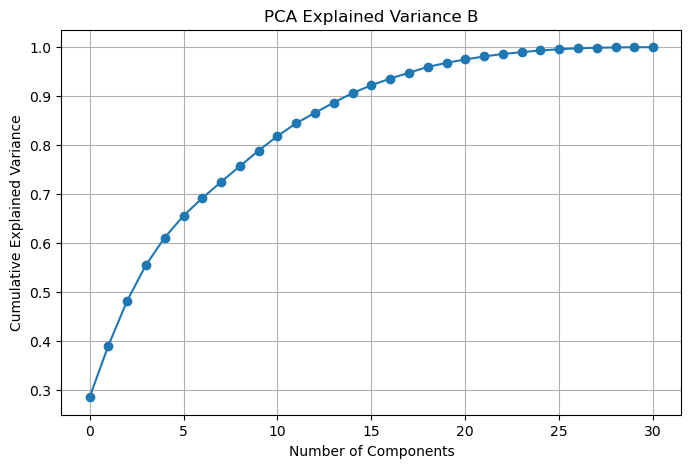

In [31]:
explained_var = pca.explained_variance_ratio_

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_var), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance B")
plt.grid(True)
plt.show()

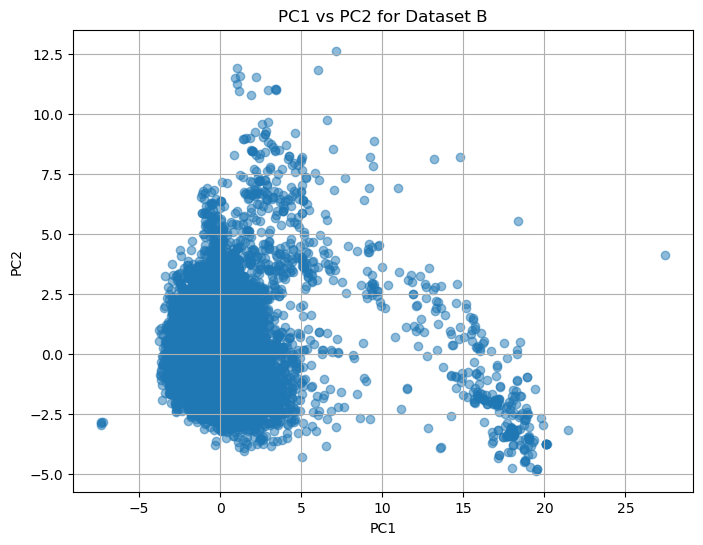

In [32]:
plt.figure(figsize=(8,6))

plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PC1 vs PC2 for Dataset B")
plt.grid(True)
plt.show()

In [19]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(feature_cols))],
    index=feature_cols
)

loadings.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31
Sample_ID,-0.036186,-0.312974,0.079275,0.012825,0.217046,0.313589,-0.243999,0.074541,0.008292,-0.209515,0.025261,0.195797,0.273082,-0.252321,0.279375,-0.464858,0.016953,-0.054373,-0.166613,-0.246991,-0.159008,0.192802,-0.038441,-0.094927,-0.026993,0.041172,0.005417,0.005294,0.020335,-0.024063,0.000137
Latitude_Degrees,0.002303,0.077223,-0.388753,0.277965,0.195765,-0.279354,-0.007573,-0.046310,0.105840,0.086832,0.032411,0.041029,0.024685,-0.113875,-0.019285,0.362488,-0.020563,-0.192957,-0.164033,-0.174550,-0.410988,0.394027,-0.017062,-0.244303,-0.001992,0.001140,-0.022813,0.009544,-0.013210,0.016895,0.000937
Longitude_Degrees,0.067770,0.089887,0.359759,-0.093166,-0.401931,-0.031224,0.034340,-0.036649,0.063795,0.069301,-0.028988,-0.074812,-0.200489,0.231158,-0.300182,-0.353776,0.025252,-0.055534,0.037502,-0.084158,-0.355407,0.411712,-0.073826,-0.180040,0.100372,0.038656,-0.021496,-0.002422,0.044295,0.008523,0.001322
Distance_to_Shore,-0.005068,0.027404,0.034304,-0.139380,-0.096157,0.472483,0.170816,-0.203852,0.322763,0.296823,0.021310,0.607617,-0.178792,-0.002333,0.113344,0.240944,-0.017139,-0.035632,0.033828,0.010249,-0.055470,0.008737,-0.049740,0.005407,-0.034866,-0.018786,-0.007526,0.020589,0.006683,0.005571,0.000245
Turbidity,0.089573,0.024352,-0.033956,0.312033,-0.087433,0.286048,-0.208711,0.182968,-0.174210,-0.109231,-0.295870,0.120012,0.324235,0.637916,0.003349,0.204874,-0.057884,0.021967,0.089073,-0.014940,-0.076357,-0.021924,0.013368,-0.072868,-0.030984,0.047022,0.011905,-0.030523,0.001306,0.007266,0.000300


In [20]:
loadings["PC1"].sort_values(key=abs, ascending=False).head(10)

SSTA_DHW_Standard_Deviation    0.318359
SSTA_FrequencyMean             0.296617
SSTA_Standard_Deviation        0.294591
TSA_DHWMax                     0.287540
TSA_FrequencyMean              0.280008
SSTA_DHWMax                    0.276234
TSA_Frequency                  0.263277
TSA_DHW                        0.260282
SSTA_DHW                       0.252452
TSA_Maximum                    0.222697
Name: PC1, dtype: float64

In [21]:
loadings["PC2"].sort_values(key=abs, ascending=False).head(10)

Temperature_Mean                    -0.443024
Temperature_Kelvin                  -0.408630
Temperature_Minimum                 -0.393517
TSA                                 -0.323819
Sample_ID                           -0.312974
Windspeed                            0.213418
Temperature_Maximum                 -0.206570
SSTA                                -0.178383
SSTA_Frequency_Standard_Deviation    0.168182
ClimSST                             -0.112457
Name: PC2, dtype: float64

c:\Users\gaery\miniconda3\envs\myenv\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


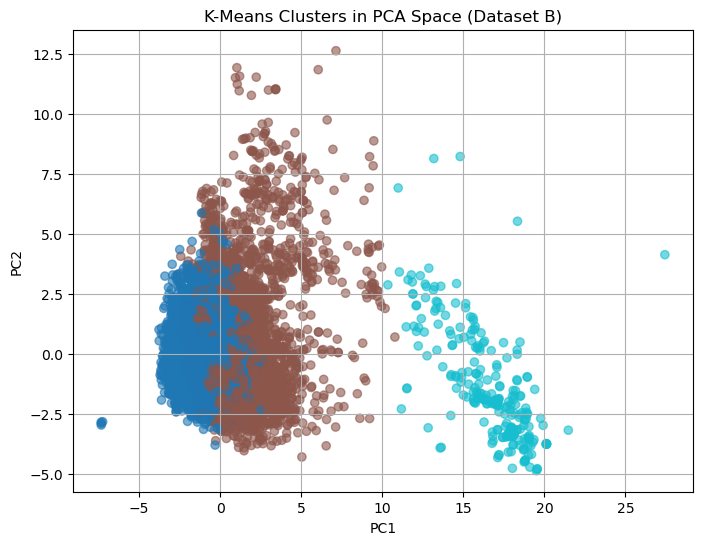

In [35]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca[:, :5])  # use top PCs

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="tab10",
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters in PCA Space (Dataset B)")
plt.grid(True)
plt.show()

In [23]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca[:, :15])

c:\Users\gaery\miniconda3\envs\myenv\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [24]:
df["cluster"] = clusters

df_bleach = df.dropna(subset=["Percent_Bleaching"]).copy()

df_bleach.groupby("cluster")["Percent_Bleaching"].mean()

cluster
0    16.041802
1    23.620109
2    17.735153
Name: Percent_Bleaching, dtype: float64

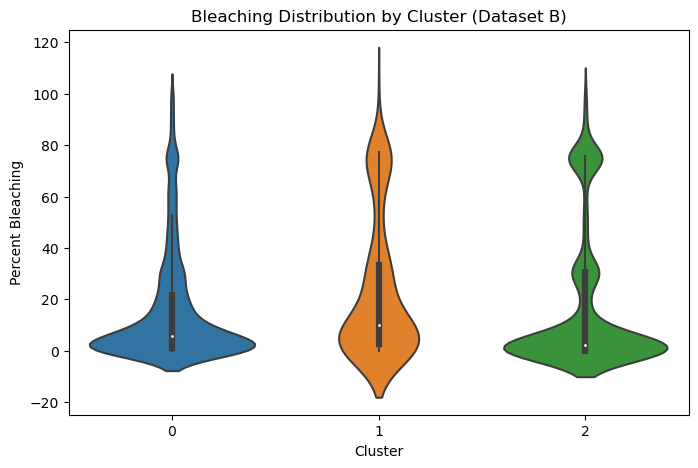

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.violinplot(x="cluster", y="Percent_Bleaching", data=df_bleach)

plt.title("Bleaching Distribution by Cluster (Dataset B)")
plt.xlabel("Cluster")
plt.ylabel("Percent Bleaching")

plt.show()

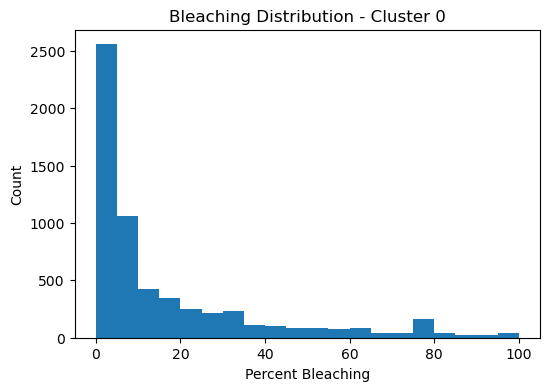

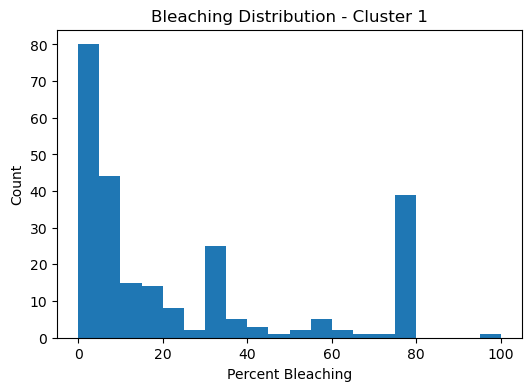

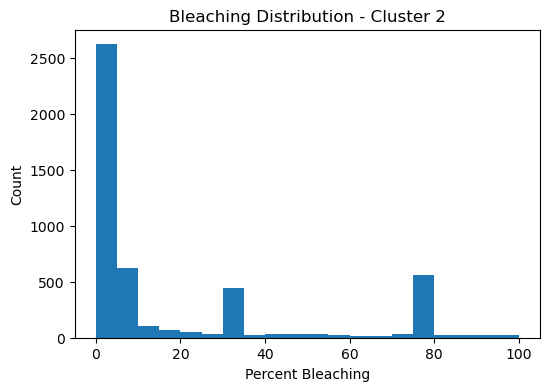

In [26]:
for c in sorted(df_bleach["cluster"].unique()):
    subset = df_bleach[df_bleach["cluster"] == c]
    
    plt.figure(figsize=(6,4))
    plt.hist(subset["Percent_Bleaching"], bins=20)
    
    plt.title(f"Bleaching Distribution - Cluster {c}")
    plt.xlabel("Percent Bleaching")
    plt.ylabel("Count")
    
    plt.show()

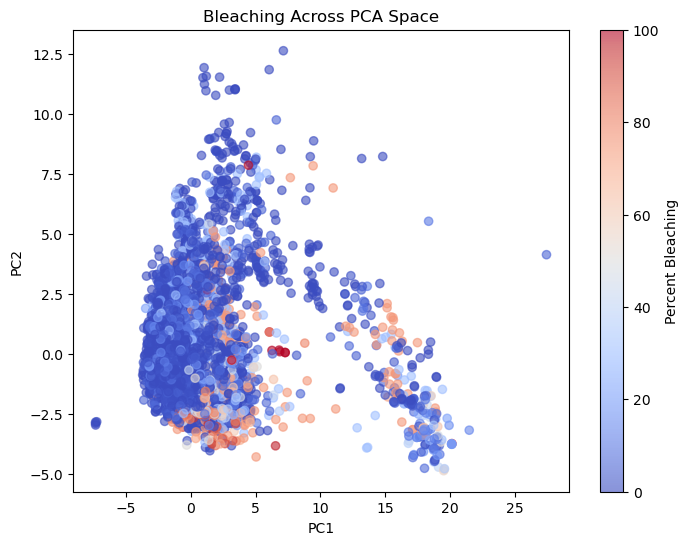

In [27]:
bleach_idx = df_bleach.index

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[bleach_idx, 0],
    X_pca[bleach_idx, 1],
    c=df_bleach["Percent_Bleaching"],
    cmap="coolwarm",
    alpha=0.6
)

plt.colorbar(scatter, label="Percent Bleaching")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Bleaching Across PCA Space")
plt.show()

In [28]:
for i in range(20):
    corr = np.corrcoef(
        X_pca[bleach_idx, i],
        df_bleach["Percent_Bleaching"]
    )[0,1]
    
    print(f"PC{i+1} correlation with bleaching:", corr)

PC1 correlation with bleaching: 0.12454099314954889
PC2 correlation with bleaching: -0.08058884166949397
PC3 correlation with bleaching: -0.1421519277560426
PC4 correlation with bleaching: -0.20376273552123525
PC5 correlation with bleaching: -0.16181932221592107
PC6 correlation with bleaching: 0.08060835280781337
PC7 correlation with bleaching: 0.04476844254509449
PC8 correlation with bleaching: 0.21244816910500364
PC9 correlation with bleaching: 0.06267042935900091
PC10 correlation with bleaching: 0.025612795524680907
PC11 correlation with bleaching: -0.11261075233020311
PC12 correlation with bleaching: -0.0718515748988581
PC13 correlation with bleaching: 0.04234333563596451
PC14 correlation with bleaching: -0.03916358533403131
PC15 correlation with bleaching: -0.00888286884521936
PC16 correlation with bleaching: -0.01817883611979055
PC17 correlation with bleaching: 0.06866677670988353
PC18 correlation with bleaching: 0.1446362273127457
PC19 correlation with bleaching: -0.066229051519

In [29]:
from sklearn.linear_model import LinearRegression

X_reg = X_pca[bleach_idx, :15]
y_reg = df_bleach["Percent_Bleaching"]

model = LinearRegression()
model.fit(X_reg, y_reg)

print("R^2:", model.score(X_reg, y_reg))

R^2: 0.19012656540509354


In [30]:
loadings["PC8"].sort_values(key=abs, ascending=False).head(10)

Percent_Cover          0.643435
SSTA_Frequency         0.375332
ClimSST               -0.275371
Distance_to_Shore     -0.203852
SSTA_DHW               0.185635
Turbidity              0.182968
TSA_FrequencyMean     -0.167257
Temperature_Maximum    0.156617
Depth_m                0.154207
TSA                   -0.151426
Name: PC8, dtype: float64

Text(0.5, 1.0, 'Bleaching Across PCA Space')

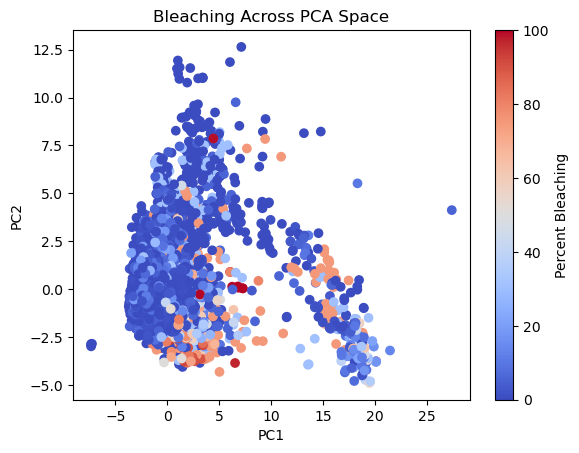

In [34]:
plt.scatter(X_pca[bleach_idx,0], X_pca[bleach_idx,1], 
            c=df_bleach["Percent_Bleaching"], cmap="coolwarm")
plt.colorbar(label="Percent Bleaching")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Bleaching Across PCA Space")